# Bangkok Open-Meteo Rain-Any Baseline Models (V0)

The **baseline arm** for `BKK_Rain_V1`, and the Open-Meteo counterpart to `TMD_BKK_V0`.

`TMD_BKK_V0` (40 features) could not be compared against `BKK_Rain_V1` (66 features)
without conflating two variables at once — data source *and* feature-set size. This
notebook removes the second one: it is `BKK_Rain_V1` with the 30 neighbourhood-grid
features withheld, leaving the 36 own-cell baseline columns.

| | V0 (this notebook) | V1 |
|---|---|---|
| own-cell baseline | 36 | 36 |
| **neighbourhood grid** | **0** | **30** |
| **total features** | **36** | **66** |
| rows, split, hyperparameters, threshold protocol | identical | identical |

## Same controlled-ablation discipline as TMD_BKK_V0

`BKK_Rain_V1`'s `ROW_FILTER_SQL` ends with `AND neighbor_count > 0`. Dropping the
neighbourhood columns from the query would change which rows survive, and V0 would then
differ from V1 in both its features and its training set. So the filter is kept verbatim
and only `FEATURE_COLUMNS` changes. Section 4b asserts the row count, grid count and both
split boundaries match V1's saved metadata.

## What this does and does not license

It makes the **feature-set** variable comparable between the Open-Meteo grid and the TMD
station network: V0-vs-V0 is 36 own-cell features against 40 own-station features, each
with its spatial block withheld.

It does **not** make the two ROC/F1 numbers rankable against each other. `BKK_Rain_V0` is
still graded by Open-Meteo `precipitation` (ECMWF model output, which also feeds its own
`precipitation*` features) and `TMD_BKK_V0` by the station gauge. Experiment 07 measured
those records agreeing on only 11–19% of rainy hours, and the co-located head-to-head in
`Data_Analysis/compare_tmd_vs_om_on_imerg.py` shows every model peaking on whichever
record it trained on. The label confound is untouched by this notebook — only the feature
confound is.

## 1. Setup

In [1]:
import json
import os
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 180)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 2. Configuration

Copied from `BKK_Rain_V1` unchanged except `MODEL_DIR` and `FEATURE_SET_NAME`.

In [2]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

TABLE_NAME = '"OM_BKK_DATA"'
PRECOMPUTE_TABLE_NAME = '"OM_BKK_DATA_PRECOMPUTE"'
PROJECT_ROOT = Path.cwd()
MODEL_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "om_bkk_rain_any_v0_baseline"
V1_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "om_bkk_rain_any_v1"

FEATURE_SET_NAME = "baseline"

HORIZONS = [1, 2, 3, 6]
RAIN_THRESHOLD_MM = 0.1
PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.10, 0.91, 0.05)

MODEL_PLAN = {
    1: "lightgbm",
    2: "lightgbm",
    3: "hist_gradient_boosting",
    6: "hist_gradient_boosting",
}

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
SAMPLE_ROWS = None
RANDOM_STATE = 42

USE_LIGHTGBM_EARLY_STOPPING = True
LIGHTGBM_N_ESTIMATORS = 1500
LIGHTGBM_EARLY_STOPPING_ROUNDS = 60

print(f"Source table    : {PRECOMPUTE_TABLE_NAME}")
print(f"Horizons        : {HORIZONS}")
print(f"LGBM early stop : {USE_LIGHTGBM_EARLY_STOPPING}")

Source table    : "OM_BKK_DATA_PRECOMPUTE"
Horizons        : [1, 2, 3, 6]
LGBM early stop : True


## 3. Feature Columns

Both blocks declared as in V1 so the row filter is unchanged. `FEATURE_COLUMNS` then omits
the neighbourhood block — that line is the entire experiment.

In [3]:
BASELINE_FEATURE_COLUMNS = [
    "temperature_2m", "relative_humidity_2m", "pressure_msl", "surface_pressure",
    "dew_point_2m", "precipitation", "cloud_cover", "wind_speed_10m",
    "wind_direction_10m", "temperature_dew_point_spread", "pressure_msl_change_3h",
    "pressure_msl_change_6h", "precipitation_lag_1h", "precipitation_lag_2h",
    "precipitation_lag_3h", "precipitation_lag_6h", "precipitation_sum_past_3h",
    "precipitation_sum_past_6h", "precipitation_sum_past_12h", "precipitation_sum_past_24h",
    "cloud_cover_lag_1h", "cloud_cover_lag_3h", "cloud_cover_lag_6h",
    "humidity_lag_1h", "humidity_lag_3h", "humidity_lag_6h",
    "wind_speed_lag_1h", "wind_speed_lag_3h", "hour_sin", "hour_cos",
    "month_sin", "month_cos", "grid_row", "grid_column", "latitude", "longitude",
]

# Declared but NOT given to the model. `neighbor_count` is still used by the row filter.
NEIGHBOR_FEATURE_COLUMNS = [
    "neighbor_count", "neighbor_precipitation_mean", "neighbor_precipitation_max",
    "neighbor_precipitation_sum", "neighbor_rain_count", "neighbor_rain_rate",
    "neighbor_cloud_cover_mean", "neighbor_cloud_cover_max", "neighbor_relative_humidity_mean",
    "neighbor_relative_humidity_max", "neighbor_pressure_msl_mean", "neighbor_pressure_msl_min",
    "neighbor_pressure_msl_max", "neighbor_temperature_2m_mean", "neighbor_dew_point_2m_mean",
    "neighbor_temperature_dew_point_spread_mean", "neighbor_wind_speed_10m_mean",
    "neighbor_wind_speed_10m_max", "row_minus_precipitation_mean", "row_plus_precipitation_mean",
    "column_minus_precipitation_mean", "column_plus_precipitation_mean", "row_minus_cloud_cover_mean",
    "row_plus_cloud_cover_mean", "column_minus_cloud_cover_mean", "column_plus_cloud_cover_mean",
    "neighbor_precipitation_mean_minus_center", "neighbor_cloud_cover_mean_minus_center",
    "neighbor_relative_humidity_mean_minus_center", "center_pressure_msl_minus_neighbor_mean",
]

# >>> THE ONLY LINE THAT DIFFERS FROM V1 <<<
FEATURE_COLUMNS = BASELINE_FEATURE_COLUMNS

TARGET_COLUMNS = [f"rain_any_next_{horizon}h" for horizon in HORIZONS]

assert not set(FEATURE_COLUMNS) & set(NEIGHBOR_FEATURE_COLUMNS), \
    "V0 must not contain any neighbourhood feature"

print(f"Features used: {len(FEATURE_COLUMNS)}   (V1 used 66)")
print(f"  own-cell baseline   : {len(BASELINE_FEATURE_COLUMNS)}")
print(f"  neighbourhood grid  : 0  (withheld; {len(NEIGHBOR_FEATURE_COLUMNS)} available)")
print(f"Targets: {TARGET_COLUMNS}")

Features used: 36   (V1 used 66)
  own-cell baseline   : 36
  neighbourhood grid  : 0  (withheld; 30 available)
Targets: ['rain_any_next_1h', 'rain_any_next_2h', 'rain_any_next_3h', 'rain_any_next_6h']


## 4. Load Precomputed Training Data

Loader verbatim from V1. `ROW_FILTER_SQL` keeps `neighbor_count > 0` so the surviving row
set is identical.

In [4]:
ROW_FILTER_SQL = f'''
    WHERE pressure_msl_change_6h IS NOT NULL
      AND precipitation_lag_6h IS NOT NULL
      AND precipitation_sum_past_24h IS NOT NULL
      AND cloud_cover_lag_6h IS NOT NULL
      AND humidity_lag_6h IS NOT NULL
      AND wind_speed_lag_3h IS NOT NULL
      AND rain_any_next_{max(HORIZONS)}h IS NOT NULL
      AND neighbor_count > 0
'''


def connect():
    return psycopg2.connect(**DB_CONFIG)


def count_training_rows(conn):
    with conn.cursor() as cur:
        cur.execute(f"SELECT count(*) FROM {PRECOMPUTE_TABLE_NAME} {ROW_FILTER_SQL}")
        return cur.fetchone()[0]


def read_training_data(sample_rows=None, batch_size=250_000):
    """Stream the training panel into preallocated float32 / int8 arrays."""
    feature_sql = ",\n        ".join(
        f"COALESCE({c}::real, 'NaN'::real) AS {c}" for c in FEATURE_COLUMNS
    )
    target_sql = ",\n        ".join(f"{t}::smallint" for t in TARGET_COLUMNS)
    query = f'''
    SELECT
        grid_number,
        local_forecast_time,
        {feature_sql},
        {target_sql}
    FROM {PRECOMPUTE_TABLE_NAME}
    {ROW_FILTER_SQL}
    ORDER BY local_forecast_time, grid_number
    '''

    with connect() as conn:
        total_rows = count_training_rows(conn)
        n_rows = min(total_rows, sample_rows) if sample_rows else total_rows
        if sample_rows:
            query += f"\n    LIMIT {int(sample_rows)}"
        print(f"Allocating {n_rows:,} rows x {len(FEATURE_COLUMNS)} features "
              f"({n_rows * len(FEATURE_COLUMNS) * 4 / 1e9:.2f} GB float32)")

        x = np.empty((n_rows, len(FEATURE_COLUMNS)), dtype="float32")
        y = np.empty((n_rows, len(TARGET_COLUMNS)), dtype="int8")
        forecast_time = np.empty(n_rows, dtype="datetime64[s]")
        grid_number = np.empty(n_rows, dtype="int32")

        n_feat = len(FEATURE_COLUMNS)
        filled = 0
        with conn.cursor(name="bkk_v0_training_stream") as cur:
            cur.itersize = batch_size
            cur.execute(query)
            while filled < n_rows:
                batch = cur.fetchmany(batch_size)
                if not batch:
                    break
                block = np.asarray(batch, dtype="object")
                take = min(len(batch), n_rows - filled)
                grid_number[filled:filled + take] = block[:take, 0].astype("int32")
                forecast_time[filled:filled + take] = block[:take, 1].astype("datetime64[s]")
                x[filled:filled + take] = block[:take, 2:2 + n_feat].astype("float32")
                y[filled:filled + take] = block[:take, 2 + n_feat:].astype("int8")
                filled += take
                print(f"  loaded {filled:,} / {n_rows:,}", end="\r", flush=True)
        print()

    if filled != n_rows:
        x, y = x[:filled], y[:filled]
        forecast_time, grid_number = forecast_time[:filled], grid_number[:filled]
    return x, y, forecast_time, grid_number

In [5]:
x_all, y_all, forecast_time, grid_number = read_training_data(SAMPLE_ROWS)

print(f"x: {x_all.shape}  y: {y_all.shape}")
print(f"{forecast_time.min()} to {forecast_time.max()}")
print(f"grids: {np.unique(grid_number).size}")
print(f"x memory: {x_all.nbytes / 1e9:.2f} GB")

nan_counts = np.isnan(x_all).sum(axis=0)
if nan_counts.any():
    display(pd.Series(nan_counts, index=FEATURE_COLUMNS).loc[lambda s: s > 0].sort_values(ascending=False))
else:
    print("No NaNs in feature matrix.")

Allocating 2,453,568 rows x 36 features (0.35 GB float32)



x: (2453568, 36)  y: (2453568, 4)
2021-07-20T06:00:00 to 2026-07-19T21:00:00
grids: 56
x memory: 0.35 GB


No NaNs in feature matrix.


### 4b. Row-Identity Check Against V1

The ablation is only interpretable if V0 and V1 trained on the same rows.

In [6]:
V1_META = json.loads((V1_DIR / "bkk_rain_v1_metadata.json").read_text(encoding="utf-8"))

identity = pd.DataFrame([
    {"quantity": "modelling rows", "V0": int(x_all.shape[0]), "V1": int(V1_META["rows"])},
    {"quantity": "grids", "V0": int(np.unique(grid_number).size), "V1": int(V1_META["grids"])},
])
identity["match"] = identity["V0"] == identity["V1"]
display(identity)

withheld = sorted(set(V1_META["feature_columns"]) - set(FEATURE_COLUMNS))
print(f"V0 feature count {len(FEATURE_COLUMNS)} vs V1 {len(V1_META['feature_columns'])}")
print(f"withheld from V0 ({len(withheld)}): {withheld}")
assert set(FEATURE_COLUMNS) < set(V1_META["feature_columns"]), \
    "V0 features must be a strict subset of V1's"
assert bool(identity["match"].all()), "row set diverged from V1 - ablation is confounded"
print("\nrow set matches V1; feature list is a strict subset. Ablation is controlled.")

,quantity,V0,V1,match
0,modelling rows,2453568,2453568,True
1,grids,56,56,True


V0 feature count 36 vs V1 66
withheld from V0 (30): ['center_pressure_msl_minus_neighbor_mean', 'column_minus_cloud_cover_mean', 'column_minus_precipitation_mean', 'column_plus_cloud_cover_mean', 'column_plus_precipitation_mean', 'neighbor_cloud_cover_max', 'neighbor_cloud_cover_mean', 'neighbor_cloud_cover_mean_minus_center', 'neighbor_count', 'neighbor_dew_point_2m_mean', 'neighbor_precipitation_max', 'neighbor_precipitation_mean', 'neighbor_precipitation_mean_minus_center', 'neighbor_precipitation_sum', 'neighbor_pressure_msl_max', 'neighbor_pressure_msl_mean', 'neighbor_pressure_msl_min', 'neighbor_rain_count', 'neighbor_rain_rate', 'neighbor_relative_humidity_max', 'neighbor_relative_humidity_mean', 'neighbor_relative_humidity_mean_minus_center', 'neighbor_temperature_2m_mean', 'neighbor_temperature_dew_point_spread_mean', 'neighbor_wind_speed_10m_max', 'neighbor_wind_speed_10m_mean', 'row_minus_cloud_cover_mean', 'row_minus_precipitation_mean', 'row_plus_cloud_cover_mean', 'row_p

## 5. Target Balance

In [7]:
target_balance = pd.DataFrame([
    {
        "horizon_h": horizon,
        "target_column": f"rain_any_next_{horizon}h",
        "rain_threshold_mm": RAIN_THRESHOLD_MM,
        "rows": int(y_all.shape[0]),
        "rain_rows": int(y_all[:, i].sum()),
        "rain_rate": float(y_all[:, i].mean()),
    }
    for i, horizon in enumerate(HORIZONS)
])
display(target_balance)

,horizon_h,target_column,rain_threshold_mm,rows,rain_rows,rain_rate
0,1,rain_any_next_1h,0.1000,2453568,541154,0.2206
1,2,rain_any_next_2h,0.1000,2453568,696173,0.2837
2,3,rain_any_next_3h,0.1000,2453568,815989,0.3326
3,6,rain_any_next_6h,0.1000,2453568,1076591,0.4388


## 6. Chronological Split

In [8]:
def time_split_bounds(times, train_fraction=0.70, validation_fraction=0.15):
    unique_times = np.unique(times)
    train_end = unique_times[int(len(unique_times) * train_fraction)]
    validation_end = unique_times[int(len(unique_times) * (train_fraction + validation_fraction))]
    train_stop = int(np.searchsorted(times, train_end, side="left"))
    validation_stop = int(np.searchsorted(times, validation_end, side="left"))
    return train_end, validation_end, train_stop, validation_stop


train_end, validation_end, train_stop, validation_stop = time_split_bounds(
    forecast_time, TRAIN_FRACTION, VALIDATION_FRACTION
)
print(f"Train before: {train_end}   (V1: {V1_META['train_end_exclusive']})")
print(f"Validation before: {validation_end}   (V1: {V1_META['validation_end_exclusive']})")
assert str(train_end) == V1_META["train_end_exclusive"], "split boundary diverged from V1"
assert str(validation_end) == V1_META["validation_end_exclusive"], "split boundary diverged from V1"

x_train, x_validation, x_test = x_all[:train_stop], x_all[train_stop:validation_stop], x_all[validation_stop:]
y_train_all, y_validation_all, y_test_all = y_all[:train_stop], y_all[train_stop:validation_stop], y_all[validation_stop:]

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(x_train),
     "from": str(forecast_time[:train_stop].min()), "to": str(forecast_time[:train_stop].max()),
     **{f"rain_rate_{h}h": float(y_train_all[:, i].mean()) for i, h in enumerate(HORIZONS)}},
    {"split": "validation", "rows": len(x_validation),
     "from": str(forecast_time[train_stop:validation_stop].min()), "to": str(forecast_time[train_stop:validation_stop].max()),
     **{f"rain_rate_{h}h": float(y_validation_all[:, i].mean()) for i, h in enumerate(HORIZONS)}},
    {"split": "test", "rows": len(x_test),
     "from": str(forecast_time[validation_stop:].min()), "to": str(forecast_time[validation_stop:].max()),
     **{f"rain_rate_{h}h": float(y_test_all[:, i].mean()) for i, h in enumerate(HORIZONS)}},
])
display(split_summary)
print(f"splits are zero-copy views: {x_train.base is x_all and x_test.base is x_all}")

Train before: 2025-01-18T05:00:00   (V1: 2025-01-18T05:00:00)
Validation before: 2025-10-19T01:00:00   (V1: 2025-10-19T01:00:00)


,split,rows,from,to,rain_rate_1h,rain_rate_2h,rain_rate_3h,rain_rate_6h
0,train,1717576,2021-07-20T06:00:00,2025-01-18T04:00:00,0.2227,0.2837,0.3306,0.4333
1,validation,368032,2025-01-18T05:00:00,2025-10-19T00:00:00,0.2687,0.3495,0.4111,0.5389
2,test,367960,2025-10-19T01:00:00,2026-07-19T21:00:00,0.1624,0.2184,0.2632,0.3644


splits are zero-copy views: True


## 7. Evaluation Helpers

In [9]:
def threshold_metrics(y_true, probabilities, thresholds=PROBABILITY_THRESHOLDS_TO_TEST):
    rows = []
    for threshold in thresholds:
        y_pred = (probabilities >= threshold).astype("int8")
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "probability_threshold": float(threshold),
            "predicted_rain_rate": float(y_pred.mean()),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "true_negatives": int(tn),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
        })
    return pd.DataFrame(rows)


def evaluate_probabilities(y_true, probabilities, model_name, horizon, split):
    base = {
        "model": model_name,
        "feature_set": FEATURE_SET_NAME,
        "horizon_h": horizon,
        "split": split,
        "rows": int(len(y_true)),
        "rain_rate": float(np.mean(y_true)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "brier_score": float(brier_score_loss(y_true, probabilities)),
    }
    threshold_df = threshold_metrics(y_true, probabilities)
    for key, value in base.items():
        threshold_df[key] = value
    return base, threshold_df


def best_thresholds(threshold_results):
    return (
        threshold_results.sort_values(["model", "horizon_h", "split", "f1"], ascending=[True, True, True, False])
        .groupby(["model", "horizon_h", "split"], as_index=False)
        .head(1)
        .sort_values(["model", "horizon_h", "split"])
    )


def metrics_at_thresholds(threshold_results, chosen_thresholds, split="test"):
    rows = []
    for horizon, threshold in chosen_thresholds.items():
        selected = threshold_results[
            (threshold_results["horizon_h"] == horizon)
            & (threshold_results["model"] == MODEL_PLAN[horizon])
            & (threshold_results["split"] == split)
            & (threshold_results["probability_threshold"].round(10) == round(threshold, 10))
        ]
        rows.append(selected)
    return pd.concat(rows, ignore_index=True)

## 8. Train The Four Models

Hyperparameters identical to V1, including LightGBM early stopping on the chronological
validation split.

In [10]:
try:
    from lightgbm import LGBMClassifier, early_stopping, log_evaluation
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install LightGBM first: %pip install lightgbm") from exc

models = {}
metric_rows = []
threshold_tables = []
feature_importance_rows = []
train_timings = {}
fitted_iterations = {}

for index, horizon in enumerate(HORIZONS):
    model_name = MODEL_PLAN[horizon]
    target = f"rain_any_next_{horizon}h"
    print(f"Training {model_name} for {target}...", flush=True)
    started = time.time()

    y_train = y_train_all[:, index]
    y_validation = y_validation_all[:, index]
    y_test = y_test_all[:, index]

    if model_name == "lightgbm":
        scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
        model = LGBMClassifier(
            objective="binary",
            n_estimators=LIGHTGBM_N_ESTIMATORS if USE_LIGHTGBM_EARLY_STOPPING else 500,
            learning_rate=0.04,
            num_leaves=63,
            min_child_samples=80,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
        callbacks = (
            [early_stopping(LIGHTGBM_EARLY_STOPPING_ROUNDS, verbose=False), log_evaluation(0)]
            if USE_LIGHTGBM_EARLY_STOPPING
            else [log_evaluation(0)]
        )
        model.fit(
            x_train,
            y_train,
            eval_set=[(x_validation, y_validation)],
            eval_metric="binary_logloss",
            callbacks=callbacks,
        )
        fitted_iterations[horizon] = int(model.best_iteration_ or model.n_estimators)
        for feature, importance in zip(FEATURE_COLUMNS, model.feature_importances_):
            feature_importance_rows.append({
                "model": model_name,
                "horizon_h": horizon,
                "feature": feature,
                "importance": float(importance),
            })
    elif model_name == "hist_gradient_boosting":
        model = HistGradientBoostingClassifier(
            learning_rate=0.06,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=RANDOM_STATE,
            early_stopping=False,
        )
        model.fit(x_train, y_train)
        fitted_iterations[horizon] = int(model.n_iter_)
    else:
        raise ValueError(f"Unsupported model type: {model_name}")

    models[horizon] = model
    train_timings[horizon] = time.time() - started
    print(f"  fitted in {train_timings[horizon] / 60:.1f} min "
          f"({fitted_iterations[horizon]} iterations)", flush=True)

    for split_name, x_split, y_split in [
        ("validation", x_validation, y_validation),
        ("test", x_test, y_test),
    ]:
        probabilities = model.predict_proba(x_split)[:, 1]
        metrics, thresholds = evaluate_probabilities(y_split, probabilities, model_name, horizon, split_name)
        metric_rows.append(metrics)
        threshold_tables.append(thresholds)

all_metrics = pd.DataFrame(metric_rows)
all_threshold_results = pd.concat(threshold_tables, ignore_index=True)
best_by_f1 = best_thresholds(all_threshold_results)

display(all_metrics.sort_values(["horizon_h", "split"]))

Training lightgbm for rain_any_next_1h...


C:\Users\Brandon\Documents\Phase 1\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


  fitted in 0.1 min (37 iterations)


Training lightgbm for rain_any_next_2h...


C:\Users\Brandon\Documents\Phase 1\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


...

Training hist_gradient_boosting for rain_any_next_3h...


  fitted in 0.4 min (250 iterations)


Training hist_gradient_boosting for rain_any_next_6h...


  fitted in 0.4 min (250 iterations)


,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
1,lightgbm,baseline,1,test,367960,0.1624,0.9107,0.7001,0.0902
0,lightgbm,baseline,1,validation,368032,0.2687,0.8906,0.7610,0.1293
3,lightgbm,baseline,2,test,367960,0.2184,0.8952,0.7258,0.1090
2,lightgbm,baseline,2,validation,368032,0.3495,0.8760,0.7968,0.1474
5,hist_gradient_boosting,baseline,3,test,367960,0.2632,0.8929,0.7629,0.1134
4,hist_gradient_boosting,baseline,3,validation,368032,0.4111,0.8760,0.8340,0.1411
7,hist_gradient_boosting,baseline,6,test,367960,0.3644,0.8869,0.8188,0.1328
6,hist_gradient_boosting,baseline,6,validation,368032,0.5389,0.8738,0.8857,0.1450


## 8b. Operating Threshold Selection

In [11]:
validation_best = best_by_f1[best_by_f1["split"] == "validation"]
SELECTED_PROBABILITY_THRESHOLDS = {
    int(row.horizon_h): float(row.probability_threshold)
    for row in validation_best.itertuples()
}
print("V0 selected on validation:", SELECTED_PROBABILITY_THRESHOLDS)
print("V1 selected on validation:", V1_META["selected_probability_thresholds"])

selected_threshold_metrics = metrics_at_thresholds(
    all_threshold_results, SELECTED_PROBABILITY_THRESHOLDS, split="test")

report_columns = [
    "horizon_h", "model", "probability_threshold", "rain_rate", "predicted_rain_rate",
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier_score",
    "true_positives", "false_positives", "false_negatives", "true_negatives",
]

print("\nTEST metrics at validation-selected thresholds")
display(selected_threshold_metrics[report_columns].sort_values("horizon_h"))

V0 selected on validation: {3: 0.3500000000000001, 6: 0.3500000000000001, 1: 0.5500000000000002, 2: 0.5500000000000002}
V1 selected on validation: {'3': 0.3500000000000001, '6': 0.3500000000000001, '1': 0.6000000000000002, '2': 0.5500000000000002}

TEST metrics at validation-selected thresholds


,horizon_h,model,probability_threshold,rain_rate,predicted_rain_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,true_positives,false_positives,false_negatives,true_negatives
2,1,lightgbm,0.5500,0.1624,0.1641,0.8889,0.6562,0.6632,0.6597,0.9107,0.7001,0.0902,39623,20755,20125,287457
3,2,lightgbm,0.5500,0.2184,0.2176,0.8535,0.6651,0.6629,0.6640,0.8952,0.7258,0.1090,53264,26820,27091,260785
0,3,hist_gradient_boosting,0.3500,0.2632,0.2613,0.8361,0.6899,0.6851,0.6875,0.8929,0.7629,0.1134,66343,29815,30493,241309
1,6,hist_gradient_boosting,0.3500,0.3644,0.3893,0.8051,0.7178,0.7667,0.7415,0.8869,0.8188,0.1328,102815,40420,31283,193442


## 9. Headline Metrics

The five requested values, test split, at the validation-selected threshold.

In [12]:
headline = selected_threshold_metrics[
    ["horizon_h", "model", "probability_threshold", "rain_rate",
     "roc_auc", "pr_auc", "precision", "recall", "f1"]
].sort_values("horizon_h").reset_index(drop=True)
print("=== BKK_Rain_V0 (36 baseline features, Open-Meteo labels) ===")
display(headline.round(4))

=== BKK_Rain_V0 (36 baseline features, Open-Meteo labels) ===


,horizon_h,model,probability_threshold,rain_rate,roc_auc,pr_auc,precision,recall,f1
0,1,lightgbm,0.5500,0.1624,0.9107,0.7001,0.6562,0.6632,0.6597
1,2,lightgbm,0.5500,0.2184,0.8952,0.7258,0.6651,0.6629,0.6640
2,3,hist_gradient_boosting,0.3500,0.2632,0.8929,0.7629,0.6899,0.6851,0.6875
3,6,hist_gradient_boosting,0.3500,0.3644,0.8869,0.8188,0.7178,0.7667,0.7415


## 10. Ablation — V0 versus V1

The Open-Meteo half of the same experiment run on TMD in `TMD_BKK_V0`.

In [13]:
v1_metrics = pd.read_csv(V1_DIR / "bkk_rain_v1_metrics.csv")
v1_selected = pd.read_csv(V1_DIR / "bkk_rain_v1_selected_threshold_metrics.csv")

v0_test = all_metrics[all_metrics["split"] == "test"].set_index("horizon_h")
v1_test = v1_metrics[v1_metrics["split"] == "test"].set_index("horizon_h")
v0_sel = selected_threshold_metrics.set_index("horizon_h")
v1_sel = v1_selected.set_index("horizon_h")

ablation = pd.DataFrame({
    "base_rate": v0_test["rain_rate"],
    "roc_auc_V0": v0_test["roc_auc"],
    "roc_auc_V1": v1_test["roc_auc"],
    "pr_auc_V0": v0_test["pr_auc"],
    "pr_auc_V1": v1_test["pr_auc"],
    "f1_V0": v0_sel["f1"],
    "f1_V1": v1_sel["f1"],
})
ablation["roc_auc_delta"] = ablation["roc_auc_V1"] - ablation["roc_auc_V0"]
ablation["pr_auc_delta"] = ablation["pr_auc_V1"] - ablation["pr_auc_V0"]
ablation["f1_delta"] = ablation["f1_V1"] - ablation["f1_V0"]

print("=== Open-Meteo neighbourhood-feature ablation, test split ===")
display(ablation.round(4))

=== Open-Meteo neighbourhood-feature ablation, test split ===


,base_rate,roc_auc_V0,roc_auc_V1,pr_auc_V0,pr_auc_V1,f1_V0,f1_V1,roc_auc_delta,pr_auc_delta,f1_delta
horizon_h,,,,,,,,,,
1,0.1624,0.9107,0.9255,0.7001,0.7293,0.6597,0.6809,0.0148,0.0292,0.0212
2,0.2184,0.8952,0.9118,0.7258,0.7660,0.6640,0.6891,0.0166,0.0402,0.0252
3,0.2632,0.8929,0.9024,0.7629,0.7814,0.6875,0.7039,0.0095,0.0185,0.0164
6,0.3644,0.8869,0.8928,0.8188,0.8274,0.7415,0.7495,0.0059,0.0087,0.0080


## 11. Baseline-Versus-Baseline — the comparison this notebook exists for

`BKK_Rain_V0` (36 own-cell features) against `TMD_BKK_V0` (40 own-station features), both
with their spatial blocks withheld. Feature-set scope is now matched; **the label sources
are still different**, so read this as two same-shaped models on two records, not as a
ranking.

In [14]:
TMD_V0_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "tmd_bkk_rain_any_v0_station_only"
tmd_v0_path = TMD_V0_DIR / "v0_selected_threshold_metrics.csv"

if tmd_v0_path.exists():
    tmd_v0 = pd.read_csv(tmd_v0_path)
    columns = ["horizon_h", "rain_rate", "roc_auc", "pr_auc", "precision", "recall", "f1"]
    om = headline[columns].assign(source="BKK_Rain_V0 (OM, 36 feat, OM labels)")
    tmd = tmd_v0[columns].assign(source="TMD_BKK_V0 (TMD, 40 feat, gauge labels)")
    side_by_side = (pd.concat([om, tmd])
                    .set_index(["source", "horizon_h"])
                    .sort_index()
                    .round(4))
    display(side_by_side)

    side_by_side.to_csv(MODEL_DIR.parent / "v0_baseline_vs_baseline.csv")
else:
    print(f"TMD_BKK_V0 results not found at {tmd_v0_path}; run TMD_BKK_V0.ipynb first.")

rain_rate  roc_auc  pr_auc  \
source                                  horizon_h                               
BKK_Rain_V0 (OM, 36 feat, OM labels)    1             0.1624   0.9107  0.7001   
                                        2             0.2184   0.8952  0.7258   
                                        3             0.2632   0.8929  0.7629   
                                        6             0.3644   0.8869  0.8188   
TMD_BKK_V0 (TMD, 40 feat, gauge labels) 1             0.0734   0.8833  0.5562   
                                        2             0.1075   0.8489  0.5396   
                                        3             0.1364   0.8279  0.5388   
                                        6             0.2084   0.7996  0.5676   

                                                   precision  recall     f1  
source                                  horizon_h                            
BKK_Rain_V0 (OM, 36 feat, OM labels)    1             0.6562  0.6632 0.6597  
                                        2             0.6651  0.6629 0.6640  
                                        3             0.6899  0.6851 0.6875  
                                        6             0.7178  0.7667 0.7415  
TMD_BKK_V0 (TMD, 40 feat, gauge labels) 1             0.5724  0.5280 0.5493  
                                        2             0.5394  0.4868 0.5118  
                                        3             0.5703  0.4326 0.4920  
                                        6             0.4694  0.5789 0.5185

## 12. Feature Importance (baseline only)

,model,horizon_h,feature,importance
4,lightgbm,1,dew_point_2m,240.0000
6,lightgbm,1,cloud_cover,188.0000
30,lightgbm,1,month_sin,182.0000
28,lightgbm,1,hour_sin,179.0000
29,lightgbm,1,hour_cos,167.0000
8,lightgbm,1,wind_direction_10m,155.0000
19,lightgbm,1,precipitation_sum_past_24h,133.0000
0,lightgbm,1,temperature_2m,118.0000
10,lightgbm,1,pressure_msl_change_3h,97.0000
25,lightgbm,1,humidity_lag_6h,84.0000


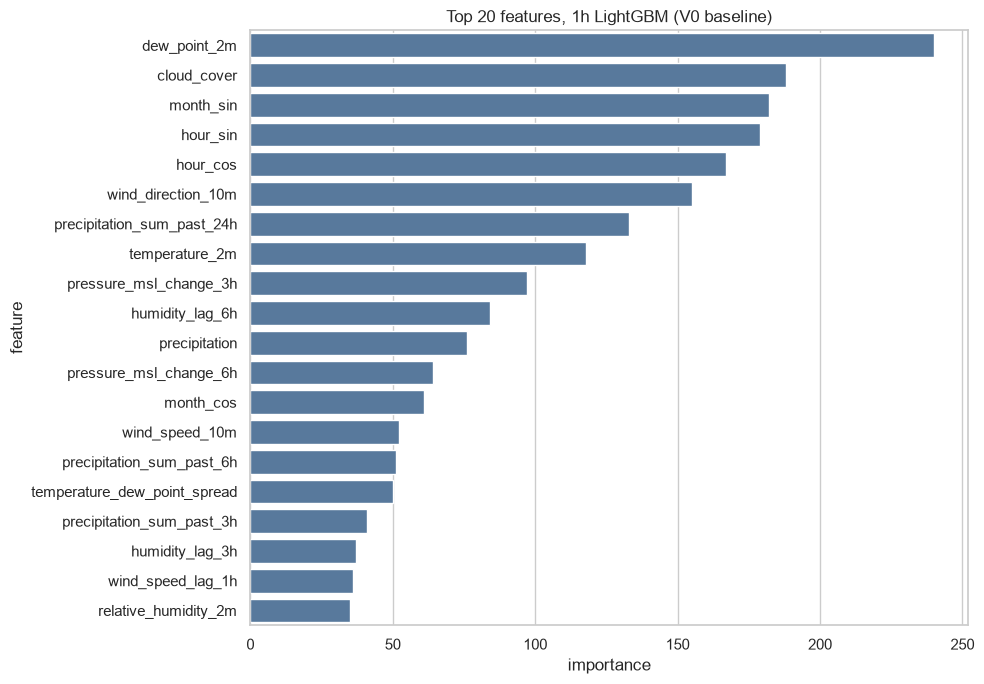

In [15]:
feature_importance = pd.DataFrame(feature_importance_rows)
if not feature_importance.empty:
    top_importance = (
        feature_importance.sort_values(["horizon_h", "importance"], ascending=[True, False])
        .groupby("horizon_h").head(15)
    )
    display(top_importance)

    fig, ax = plt.subplots(figsize=(10, 7))
    top_1h = feature_importance[feature_importance["horizon_h"] == 1].nlargest(20, "importance")
    sns.barplot(data=top_1h, y="feature", x="importance", color="#4c78a8", ax=ax)
    ax.set_title("Top 20 features, 1h LightGBM (V0 baseline)")
    plt.tight_layout()
    plt.show()

## 13. Save

In [16]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for horizon, model in models.items():
    model_name = MODEL_PLAN[horizon]
    threshold = SELECTED_PROBABILITY_THRESHOLDS[horizon]
    path = MODEL_DIR / (
        f"om_bkk_rain_any_v0_next_{horizon}h_baseline_{model_name}"
        f"_prob_threshold_{threshold:g}_rain_threshold_{RAIN_THRESHOLD_MM:g}mm.joblib"
    )
    joblib.dump(model, path)

target_balance.to_csv(MODEL_DIR / "v0_target_balance.csv", index=False)
all_metrics.to_csv(MODEL_DIR / "v0_metrics.csv", index=False)
all_threshold_results.to_csv(MODEL_DIR / "v0_probability_thresholds.csv", index=False)
best_by_f1.to_csv(MODEL_DIR / "v0_best_thresholds_by_f1.csv", index=False)
selected_threshold_metrics.to_csv(MODEL_DIR / "v0_selected_threshold_metrics.csv", index=False)
headline.to_csv(MODEL_DIR / "v0_headline_metrics.csv", index=False)
ablation.to_csv(MODEL_DIR / "v0_vs_v1_ablation.csv")
if not feature_importance.empty:
    feature_importance.to_csv(MODEL_DIR / "v0_lightgbm_feature_importance.csv", index=False)

metadata = {
    "table": TABLE_NAME,
    "precompute_table": PRECOMPUTE_TABLE_NAME,
    "feature_set": FEATURE_SET_NAME,
    "role": "baseline (own-cell) arm of the Open-Meteo neighbourhood-feature ablation",
    "compared_against": str(V1_DIR),
    "target_label_source": "Open-Meteo precipitation (ECMWF model output, not observed)",
    "model_plan": MODEL_PLAN,
    "selected_probability_thresholds": SELECTED_PROBABILITY_THRESHOLDS,
    "threshold_selection": "best F1 on validation split, evaluated once on test",
    "horizons": HORIZONS,
    "rain_threshold_mm": RAIN_THRESHOLD_MM,
    "feature_columns": FEATURE_COLUMNS,
    "withheld_neighbor_columns": NEIGHBOR_FEATURE_COLUMNS,
    "target_columns": TARGET_COLUMNS,
    "controlled_ablation_note": (
        "ROW_FILTER_SQL still requires neighbor_count > 0, so V0 and V1 train on identical "
        "rows; only FEATURE_COLUMNS differs."
    ),
    "comparability_note": (
        "matched in feature-set scope to TMD_BKK_V0 (36 own-cell vs 40 own-station), but "
        "still graded by a different label source, so the two are not rankable against "
        "each other."
    ),
    "lightgbm_early_stopping": USE_LIGHTGBM_EARLY_STOPPING,
    "fitted_iterations": fitted_iterations,
    "train_end_exclusive": str(train_end),
    "validation_end_exclusive": str(validation_end),
    "rows": int(x_all.shape[0]),
    "grids": int(np.unique(grid_number).size),
    "train_seconds": train_timings,
    "model_dir": str(MODEL_DIR),
    "metrics": all_metrics.to_dict(orient="records"),
    "selected_threshold_metrics": selected_threshold_metrics.to_dict(orient="records"),
    "ablation_vs_v1": ablation.reset_index().to_dict(orient="records"),
}
(MODEL_DIR / "v0_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved V0 baseline models and results to {MODEL_DIR}")

Saved V0 baseline models and results to C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\om_bkk_rain_any_v0_baseline
